# YOLOv11 Fine-Tuning & Export Notebook
**Project: Real-Time Multi-Object Detection & Tracking**


In [ ]:

!pip install ultralytics -q
import ultralytics
ultralytics.checks()

Ultralytics 8.4.72 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.1/112.6 GB disk)


In [ ]:

import torch
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

CUDA available: True
GPU: Tesla T4


In [ ]:

from ultralytics import YOLO
model = YOLO('yolo11n.pt')  
print(model.info())

YOLO11n summary: 181 layers, 2,624,080 parameters, 0 gradients, 6.6 GFLOPs
(181, 2624080, 0, 6.614336)


In [4]:
DATASET = 'coco128.yaml'
EPOCHS  = 20
IMGSZ   = 640
BATCH   = 16

print(f'Training on: {DATASET} for {EPOCHS} epochs')

Training on: coco128.yaml for 20 epochs


In [ ]:


# from google.colab import files
# uploaded = files.upload()   # Upload dataset.yaml
# DATASET = list(uploaded.keys())[0]

# Expected YOLO dataset format:
# dataset/
#   images/train/  images/val/
#   labels/train/  labels/val/
#   dataset.yaml   (names, nc, train/val paths)

In [ ]:
# ── 5. Fine-tune ─────────────────────────────────────────────────────────
results = model.train(
    data=DATASET,
    epochs=EPOCHS,
    imgsz=IMGSZ,
    batch=BATCH,
    device=0 if torch.cuda.is_available() else 'cpu',
    project='runs/detect',
    name='yolo11n_finetuned',
    patience=10,         
    save=True,
    plots=True,          
)
print('Training complete!')

Ultralytics 8.4.72 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco128.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11n_finetuned, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10, perspect

In [7]:
# ── 6. Evaluate on validation set ────────────────────────────────────────
best_model = YOLO('/content/runs/detect/runs/detect/yolo11n_finetuned/weights/best.pt')
metrics = best_model.val(data=DATASET, imgsz=IMGSZ, plots=True)

print(f'mAP@0.5      : {metrics.box.map50:.4f}')
print(f'mAP@0.5:0.95 : {metrics.box.map:.4f}')
print(f'Precision    : {metrics.box.mp:.4f}')
print(f'Recall       : {metrics.box.mr:.4f}')

Ultralytics 8.4.72 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,616,248 parameters, 0 gradients, 6.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1693.0±437.1 MB/s, size: 53.4 KB)
val: Scanning /content/datasets/coco128/labels/train2017.cache... 126 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 128/128 41.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 2.7it/s 2.9s
                   all        128        929      0.809      0.679      0.756      0.589
                person         61        254      0.904      0.626      0.807      0.582
               bicycle          3          6          1      0.307      0.453      0.328
                   car         12         46      0.847      0.217      0.367      0.213
            motorcycle          4          5      0.802          1      0.995      0.851
              airplane          5  

In [8]:
# ── 7. Visualize training curves ─────────────────────────────────────────
from IPython.display import Image as IPImage, display
import glob

for img_path in glob.glob('runs/detect/yolo11n_finetuned/*.png'):
    print(img_path)
    display(IPImage(img_path, width=700))

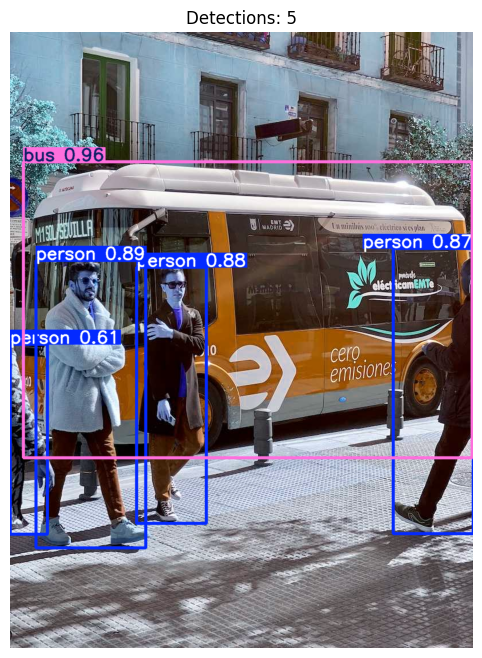

Detected 5 objects
  bus: 0.96
  person: 0.89
  person: 0.88
  person: 0.87
  person: 0.61


In [ ]:

import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt
import numpy as np


url = 'https://ultralytics.com/images/bus.jpg'
img = Image.open(BytesIO(requests.get(url).content))

results = best_model.predict(np.array(img), conf=0.35, verbose=False)
annotated = results[0].plot()

plt.figure(figsize=(12, 8))
plt.imshow(annotated[:, :, ::-1])
plt.axis('off')
plt.title(f'Detections: {len(results[0].boxes)}')
plt.show()

print(f'Detected {len(results[0].boxes)} objects')
for box in results[0].boxes:
    cls = int(box.cls[0])
    conf = float(box.conf[0])
    print(f'  {results[0].names[cls]}: {conf:.2f}')

In [ ]:

export_path = best_model.export(format='onnx', imgsz=IMGSZ, simplify=True, dynamic=False)
print(f'ONNX model saved to: {export_path}')

Ultralytics 8.4.72 🚀 Python-3.12.13 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/content/runs/detect/runs/detect/yolo11n_finetuned/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 84, 8400) (5.3 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxruntime', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 232ms
Prepared 4 packages in 1.97s
Installed 4 packages in 260ms
 + colorama==0.4.6
 + onnx==1.22.0
 + onnxruntime==1.27.0
 + onnxslim==0.1.94

requirements: AutoUpdate success ✅ 3.0s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.22.0 opset 20...
ONNX: slimming with onnxslim 0.1.94...
ONNX: export success ✅ 5.1s, saved a

In [ ]:

import time, numpy as np

dummy = np.random.randint(0, 255, (640, 640, 3), dtype=np.uint8)
times = []

# Warm up
for _ in range(5):
    best_model.predict(dummy, verbose=False)

for _ in range(100):
    t0 = time.perf_counter()
    best_model.predict(dummy, verbose=False)
    times.append((time.perf_counter() - t0) * 1000)

times = np.array(times)
print(f'Avg latency   : {times.mean():.2f} ms')
print(f'P95 latency   : {np.percentile(times, 95):.2f} ms')
print(f'FPS           : {1000/times.mean():.1f}')

Avg latency   : 9.81 ms
P95 latency   : 10.96 ms
FPS           : 102.0


In [ ]:

from google.colab import files
files.download('/content/runs/detect/runs/detect/yolo11n_finetuned/weights/best.pt')
files.download(export_path)   #  download the ONNX file

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>